<a href="https://colab.research.google.com/github/ARUNREDDYPOREDDY/EXPLAINABLE-AI/blob/main/EAI_LabExam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Import libraries
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Load dataset
df = pd.read_csv("/content/crop_yield.csv")   # update path if needed

# View initial info
print("Dataset Shape:", df.shape)
print("\nSample data:\n", df.head())
print("\nMissing values:\n", df.isnull().sum())

# Select only numeric columns for normalization
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
print("\nNumeric Columns to Normalize:\n", numeric_cols)

# Apply Min-Max Scaling
scaler = MinMaxScaler()
df_normalized = df.copy()
df_normalized[numeric_cols] = scaler.fit_transform(df[numeric_cols])

# Check normalized data
print("\nAfter Normalization:\n", df_normalized.head())

# Optional: Save normalized dataset
df_normalized.to_csv("/content/crop_yield_normalized.csv", index=False)
print("\n✅ Normalized dataset saved as 'crop_yield_normalized.csv'")


Dataset Shape: (12669, 10)

Sample data:
            Crop  Crop_Year       Season  State     Area   Production  \
0      Arecanut       1997  Whole Year   Assam  73814.0      56708.0   
1     Arhar/Tur       1997  Kharif       Assam   6637.0       4685.0   
2   Castor seed       1997  Kharif       Assam    796.0         22.0   
3      Coconut        1997  Whole Year   Assam  19656.0  126905000.0   
4  Cotton(lint)       1997  Kharif       Assam   1739.0        794.0   

   Annual_Rainfall  Fertilizer  Pesticide        Yield  
0           2051.4  7024878.38   22882.34     0.796087  
1           2051.4   631643.29    2057.47     0.710435  
2           2051.4    75755.32     246.76     0.238333  
3           2051.4  1870661.52    6093.36  5238.051739  
4           2051.4   165500.63     539.09     0.420909  

Missing values:
 Crop               0
Crop_Year          0
Season             0
State              1
Area               1
Production         1
Annual_Rainfall    1
Fertilizer        

Z-Score (Standardization) Implementation

In [ ]:
# Import required libraries
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Load dataset
df = pd.read_csv("/content/crop_yield.csv")   # Update path if needed

# Display basic info
print("Dataset Shape:", df.shape)
print("\nSample data:\n", df.head())
print("\nMissing values:\n", df.isnull().sum())

# Select numeric columns for standardization
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
print("\nNumeric Columns to Standardize:\n", numeric_cols)

# Apply Z-score Standardization
scaler = StandardScaler()
df_standardized = df.copy()
df_standardized[numeric_cols] = scaler.fit_transform(df[numeric_cols])

# Verify the transformation
print("\nAfter Standardization (mean ~0, std ~1):\n")
print(df_standardized[numeric_cols].describe().T[['mean','std']])

# Optional: Save the standardized dataset
df_standardized.to_csv("/content/crop_yield_standardized.csv", index=False)
print("\n✅ Standardized dataset saved as 'crop_yield_standardized.csv'")


Dataset Shape: (19689, 10)

Sample data:
            Crop  Crop_Year       Season  State     Area  Production  \
0      Arecanut       1997  Whole Year   Assam  73814.0       56708   
1     Arhar/Tur       1997  Kharif       Assam   6637.0        4685   
2   Castor seed       1997  Kharif       Assam    796.0          22   
3      Coconut        1997  Whole Year   Assam  19656.0   126905000   
4  Cotton(lint)       1997  Kharif       Assam   1739.0         794   

   Annual_Rainfall  Fertilizer  Pesticide        Yield  
0           2051.4  7024878.38   22882.34     0.796087  
1           2051.4   631643.29    2057.47     0.710435  
2           2051.4    75755.32     246.76     0.238333  
3           2051.4  1870661.52    6093.36  5238.051739  
4           2051.4   165500.63     539.09     0.420909  

Missing values:
 Crop               0
Crop_Year          0
Season             0
State              0
Area               0
Production         0
Annual_Rainfall    0
Fertilizer         0
Pes

In [ ]:
# Import required libraries
import pandas as pd
from sklearn.impute import SimpleImputer

# Load dataset
df = pd.read_csv("/content/crop_yield.csv")   # Update path if needed

# Check missing values
print("🔍 Missing Values Before Handling:\n")
print(df.isnull().sum())

# -----------------------------
# 1️⃣ Remove rows or columns with missing values
# -----------------------------
# Remove rows with any missing values
df_removed_rows = df.dropna()
print("\n✅ After removing rows with missing values:", df_removed_rows.shape)

# Remove columns with too many missing values (e.g., >30%)
threshold = 0.3  # 30%
df_removed_cols = df.dropna(axis=1, thresh=int((1 - threshold) * len(df)))
print("✅ After removing columns with >30% missing:", df_removed_cols.shape)

# -----------------------------
# 2️⃣ Impute missing values
# -----------------------------
# Separate numeric and categorical columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

# Mean imputation for numeric columns
mean_imputer = SimpleImputer(strategy='mean')
df[num_cols] = mean_imputer.fit_transform(df[num_cols])

# Mode imputation for categorical columns
mode_imputer = SimpleImputer(strategy='most_frequent')
df[cat_cols] = mode_imputer.fit_transform(df[cat_cols])

# -----------------------------
# ✅ Final Check
# -----------------------------
print("\n🔍 Missing Values After Imputation:\n")
print(df.isnull().sum())

# Save cleaned dataset
df.to_csv("/content/crop_yield_cleaned.csv", index=False)
print("\n✅ Cleaned dataset saved as 'crop_yield_cleaned.csv'")


🔍 Missing Values Before Handling:

Crop               0
Crop_Year          0
Season             0
State              0
Area               0
Production         0
Annual_Rainfall    0
Fertilizer         0
Pesticide          0
Yield              0
dtype: int64

✅ After removing rows with missing values: (19689, 10)
✅ After removing columns with >30% missing: (19689, 10)

🔍 Missing Values After Imputation:

Crop               0
Crop_Year          0
Season             0
State              0
Area               0
Production         0
Annual_Rainfall    0
Fertilizer         0
Pesticide          0
Yield              0
dtype: int64

✅ Cleaned dataset saved as 'crop_yield_cleaned.csv'


In [ ]:
# Import required libraries
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from collections import Counter

# Load dataset
df = pd.read_csv("/content/crop_yield_cleaned.csv")

# ---------------------------------------------
# 1️⃣ Display all available columns
# ---------------------------------------------
print("Available columns in the dataset:\n")
print(df.columns.tolist())

# ---------------------------------------------
# 2️⃣ Automatically choose or ask for target column
# ---------------------------------------------
# Try to find likely target column automatically
possible_targets = [c for c in df.columns if 'crop' in c.lower() or 'yield' in c.lower() or 'type' in c.lower() or 'label' in c.lower() or 'category' in c.lower()]

if len(possible_targets) > 0:
    target_col = possible_targets[0]
    print(f"\n🔍 Automatically detected target column: '{target_col}'")
else:
    raise ValueError("❌ Could not automatically detect target column. Please rename your target variable (e.g., 'Crop', 'Yield_Category').")

# ---------------------------------------------
# 3️⃣ Prepare data for SMOTE
# ---------------------------------------------
X = df.drop(columns=[target_col])
y = df[target_col]

# Encode categorical target if necessary
if y.dtype == 'object':
    le = LabelEncoder()
    y = le.fit_transform(y)

# Identify categorical columns in X that need one-hot encoding
categorical_cols_X = X.select_dtypes(include=['object']).columns

# Apply one-hot encoding to categorical features in X
if len(categorical_cols_X) > 0:
    X = pd.get_dummies(X, columns=categorical_cols_X, drop_first=True)
    print(f"\n✅ One-hot encoded categorical columns in X: {list(categorical_cols_X)}")

# ---------------------------------------------
# 4️⃣ Check imbalance before SMOTE
# ---------------------------------------------
print("\nClass distribution before SMOTE:")
print(Counter(y))

# ---------------------------------------------
# 5️⃣ Apply SMOTE oversampling
# ---------------------------------------------
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)

# ---------------------------------------------
# 6️⃣ Check balance after SMOTE
# ---------------------------------------------
print("\n✅ Class distribution after SMOTE:")
print(Counter(y_res))

# ---------------------------------------------
# 7️⃣ Save balanced dataset
# ---------------------------------------------
df_balanced = pd.concat([pd.DataFrame(X_res, columns=X.columns),
                         pd.DataFrame(y_res, columns=[target_col])], axis=1)
df_balanced.to_csv("/content/crop_yield_balanced.csv", index=False)
print("\n✅ Balanced dataset saved as 'crop_yield_balanced.csv'")

Available columns in the dataset:

['Crop', 'Crop_Year', 'Season', 'State', 'Area', 'Production', 'Annual_Rainfall', 'Fertilizer', 'Pesticide', 'Yield']

🔍 Automatically detected target column: 'Crop'

✅ One-hot encoded categorical columns in X: ['Season', 'State']

Class distribution before SMOTE:
Counter({np.int64(40): 1197, np.int64(24): 975, np.int64(27): 740, np.int64(52): 733, np.int64(17): 725, np.int64(43): 685, np.int64(37): 628, np.int64(46): 605, np.int64(53): 545, np.int64(39): 528, np.int64(2): 524, np.int64(20): 513, np.int64(1): 508, np.int64(38): 498, np.int64(16): 490, np.int64(44): 485, np.int64(11): 476, np.int64(31): 454, np.int64(47): 441, np.int64(13): 419, np.int64(34): 382, np.int64(19): 371, np.int64(36): 369, np.int64(50): 364, np.int64(32): 355, np.int64(45): 349, np.int64(51): 337, np.int64(25): 324, np.int64(15): 323, np.int64(23): 308, np.int64(8): 300, np.int64(4): 297, np.int64(48): 273, np.int64(14): 250, np.int64(3): 245, np.int64(26): 210, np.int64(49


🔍 Correlation Matrix:

                 Crop_Year      Area  Production  Annual_Rainfall  Fertilizer  \
Crop_Year         1.000000 -0.035686    0.003366        -0.011187    0.011169   
Area             -0.035686  1.000000    0.037441        -0.106054    0.973255   
Production        0.003366  0.037441    1.000000         0.029879    0.039799   
Annual_Rainfall  -0.011187 -0.106054    0.029879         1.000000   -0.109734   
Fertilizer        0.011169  0.973255    0.039799        -0.109734    1.000000   
Pesticide        -0.004657  0.973479    0.035171        -0.097657    0.954991   
Yield             0.002539  0.001858    0.570809         0.020761    0.002862   

                 Pesticide     Yield  
Crop_Year        -0.004657  0.002539  
Area              0.973479  0.001858  
Production        0.035171  0.570809  
Annual_Rainfall  -0.097657  0.020761  
Fertilizer        0.954991  0.002862  
Pesticide         1.000000  0.001782  
Yield             0.001782  1.000000  


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128279 (\N{LINK SYMBOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


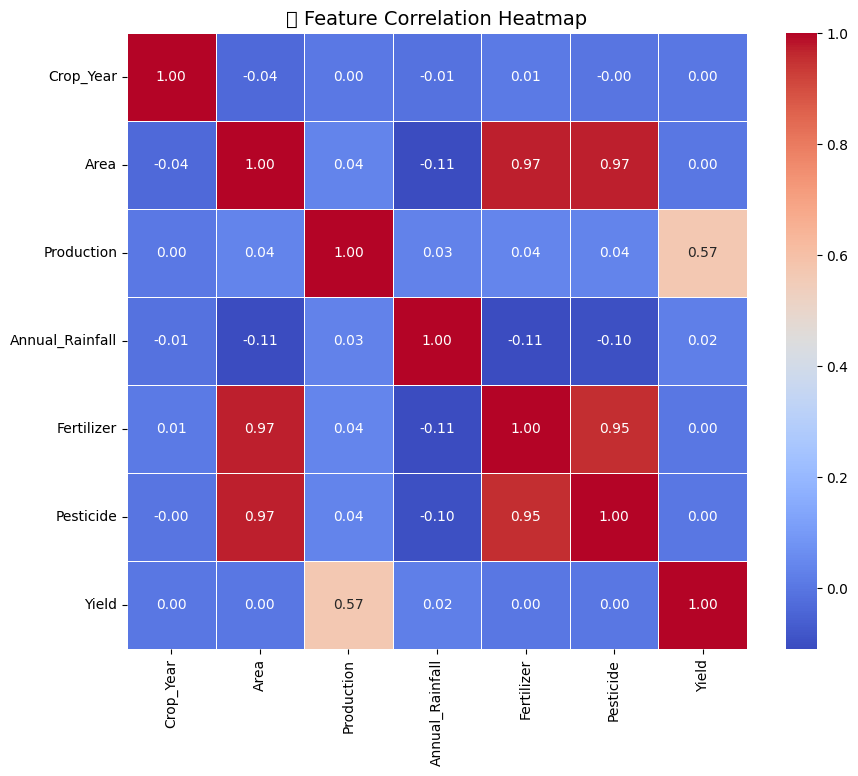


⚠️ Highly Correlated Feature Pairs (|corr| > 0.85):
Area ↔ Fertilizer : 0.97
Area ↔ Pesticide : 0.97
Fertilizer ↔ Pesticide : 0.95

✅ Removed highly correlated features: ['Pesticide', 'Fertilizer']
📁 Saved reduced dataset as 'crop_yield_reduced.csv'


In [ ]:
# Import libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv("/content/crop_yield_cleaned.csv")

# ---------------------------------------------
# 1️⃣ Select only numeric columns
# ---------------------------------------------
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# ---------------------------------------------
# 2️⃣ Compute correlation matrix
# ---------------------------------------------
corr_matrix = numeric_df.corr()

# Display correlation matrix
print("\n🔍 Correlation Matrix:\n")
print(corr_matrix)

# ---------------------------------------------
# 3️⃣ Plot heatmap
# ---------------------------------------------
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("🔗 Feature Correlation Heatmap", fontsize=14)
plt.show()

# ---------------------------------------------
# 4️⃣ Identify highly correlated features (|corr| > 0.85)
# ---------------------------------------------
threshold = 0.85
corr_pairs = corr_matrix.abs().unstack().sort_values(ascending=False)
high_corr = [(col1, col2, corr_matrix.loc[col1, col2])
              for col1 in corr_matrix.columns
              for col2 in corr_matrix.columns
              if col1 != col2 and abs(corr_matrix.loc[col1, col2]) > threshold]

# Remove duplicates (A,B) and (B,A)
unique_high_corr = []
seen = set()
for a, b, corr in high_corr:
    if (b, a) not in seen:
        unique_high_corr.append((a, b, corr))
        seen.add((a, b))

print("\n⚠️ Highly Correlated Feature Pairs (|corr| > 0.85):")
if len(unique_high_corr) == 0:
    print("✅ No highly correlated features found.")
else:
    for a, b, corr in unique_high_corr:
        print(f"{a} ↔ {b} : {corr:.2f}")

# ---------------------------------------------
# 5️⃣ (Optional) Remove one of each correlated pair
# ---------------------------------------------
features_to_drop = list({b for a, b, corr in unique_high_corr})
if features_to_drop:
    df_reduced = df.drop(columns=features_to_drop)
    print(f"\n✅ Removed highly correlated features: {features_to_drop}")
    df_reduced.to_csv("/content/crop_yield_reduced.csv", index=False)
    print("📁 Saved reduced dataset as 'crop_yield_reduced.csv'")
else:
    print("\n✅ Dataset has no multicollinearity — no features removed.")


✅ Model R² Score: 0.904


100%|===================| 3923/3938 [03:06<00:00]       

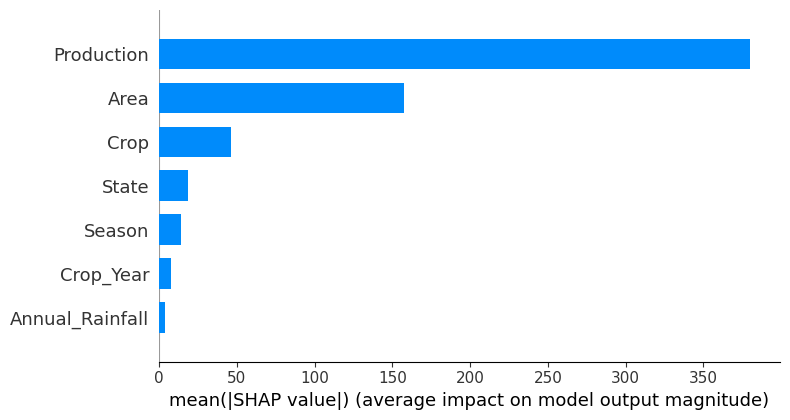

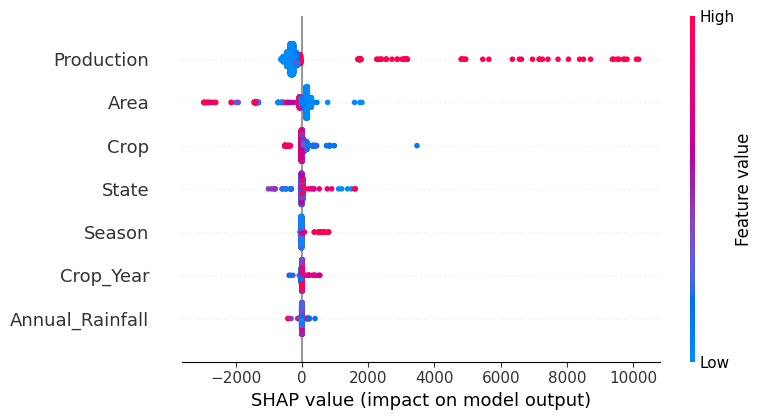

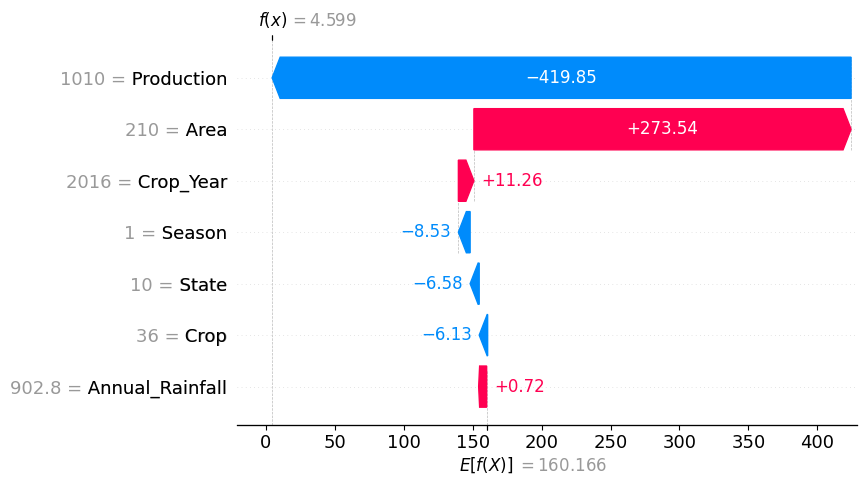

In [ ]:
# Install shap if not already installed
!pip install shap --quiet

# Import required libraries
import pandas as pd
import shap
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score

# ---------------------------------------------
# 1️⃣ Load dataset
# ---------------------------------------------
df = pd.read_csv("/content/crop_yield_reduced.csv")

# Replace with your actual target column
target_col = "Yield"  # change this if your dataset has a different target

# ---------------------------------------------
# 2️⃣ Encode categorical features
# ---------------------------------------------
df_encoded = df.copy()
for col in df_encoded.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])

# ---------------------------------------------
# 3️⃣ Split features and target
# ---------------------------------------------
X = df_encoded.drop(columns=[target_col])
y = df_encoded[target_col]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ---------------------------------------------
# 4️⃣ Train Model
# ---------------------------------------------
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

# Model performance
y_pred = model.predict(X_test)
print("✅ Model R² Score:", round(r2_score(y_test, y_pred), 3))

# ---------------------------------------------
# 5️⃣ SHAP Analysis
# ---------------------------------------------
explainer = shap.Explainer(model, X_train)
shap_values = explainer(X_test)

# Global feature importance
shap.summary_plot(shap_values, X_test, plot_type="bar")

# Detailed SHAP summary
shap.summary_plot(shap_values, X_test)

# Single sample explanation
shap.plots.waterfall(shap_values[0])


Numeric Columns: ['Crop_Year', 'Area', 'Production', 'Annual_Rainfall', 'Yield']
Categorical Columns: ['Crop', 'Season', 'State']


/tmp/ipython-input-548216575.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x=categorical_col, y=numeric_y, palette="viridis")


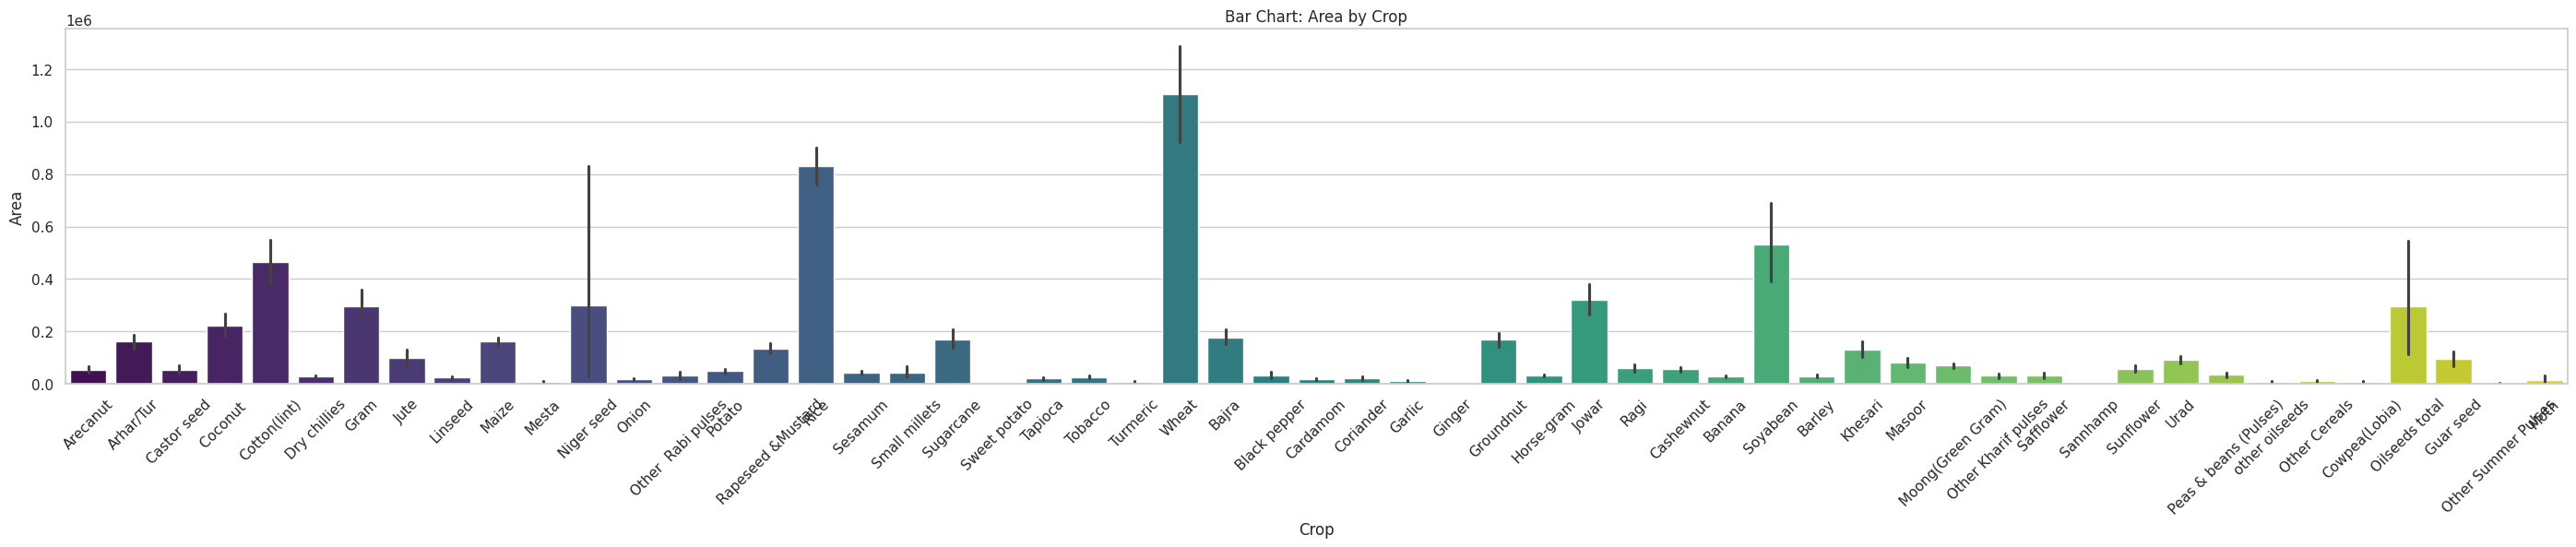

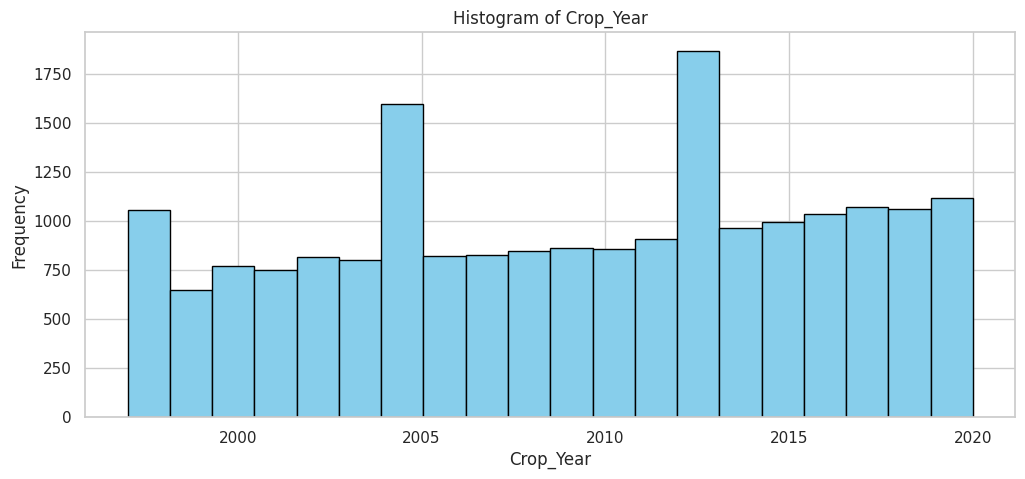

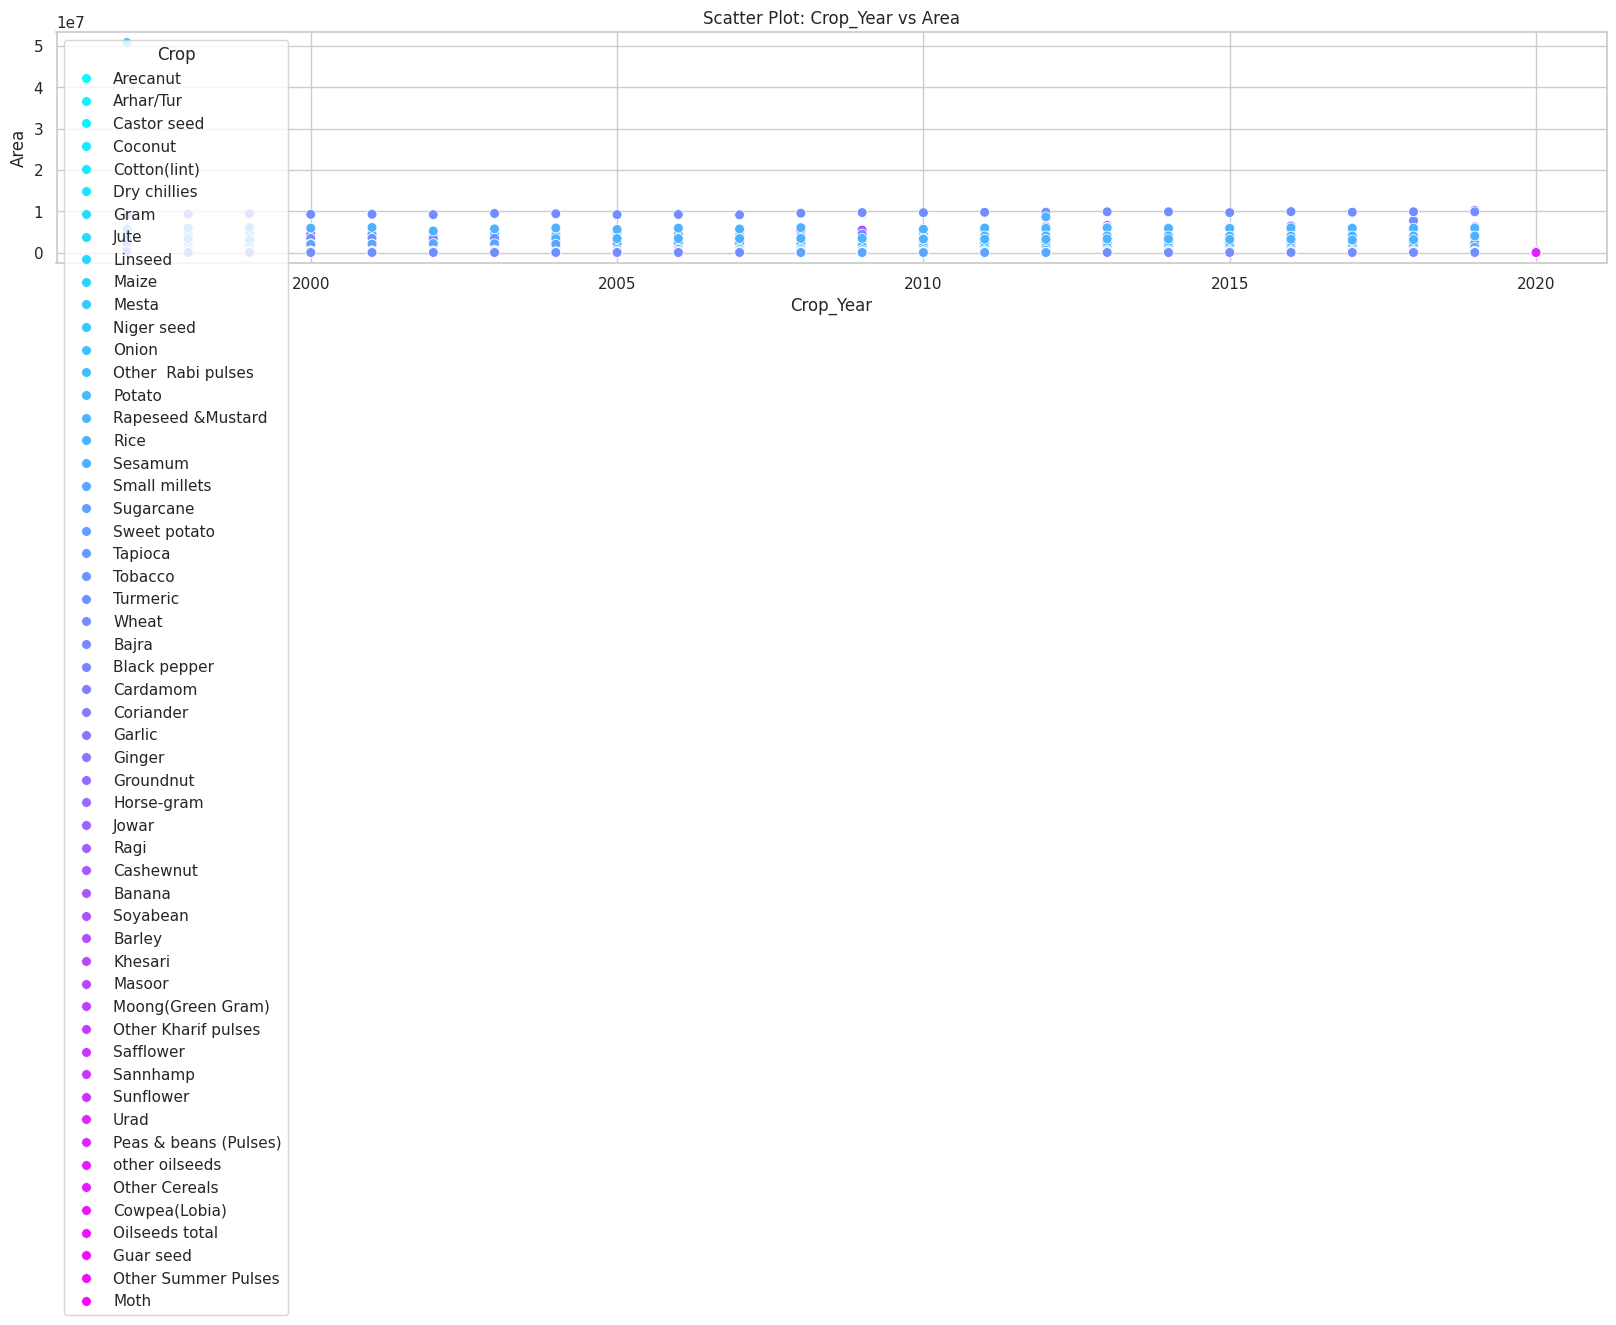

/tmp/ipython-input-548216575.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=categorical_col, y=numeric_y, palette="pastel")


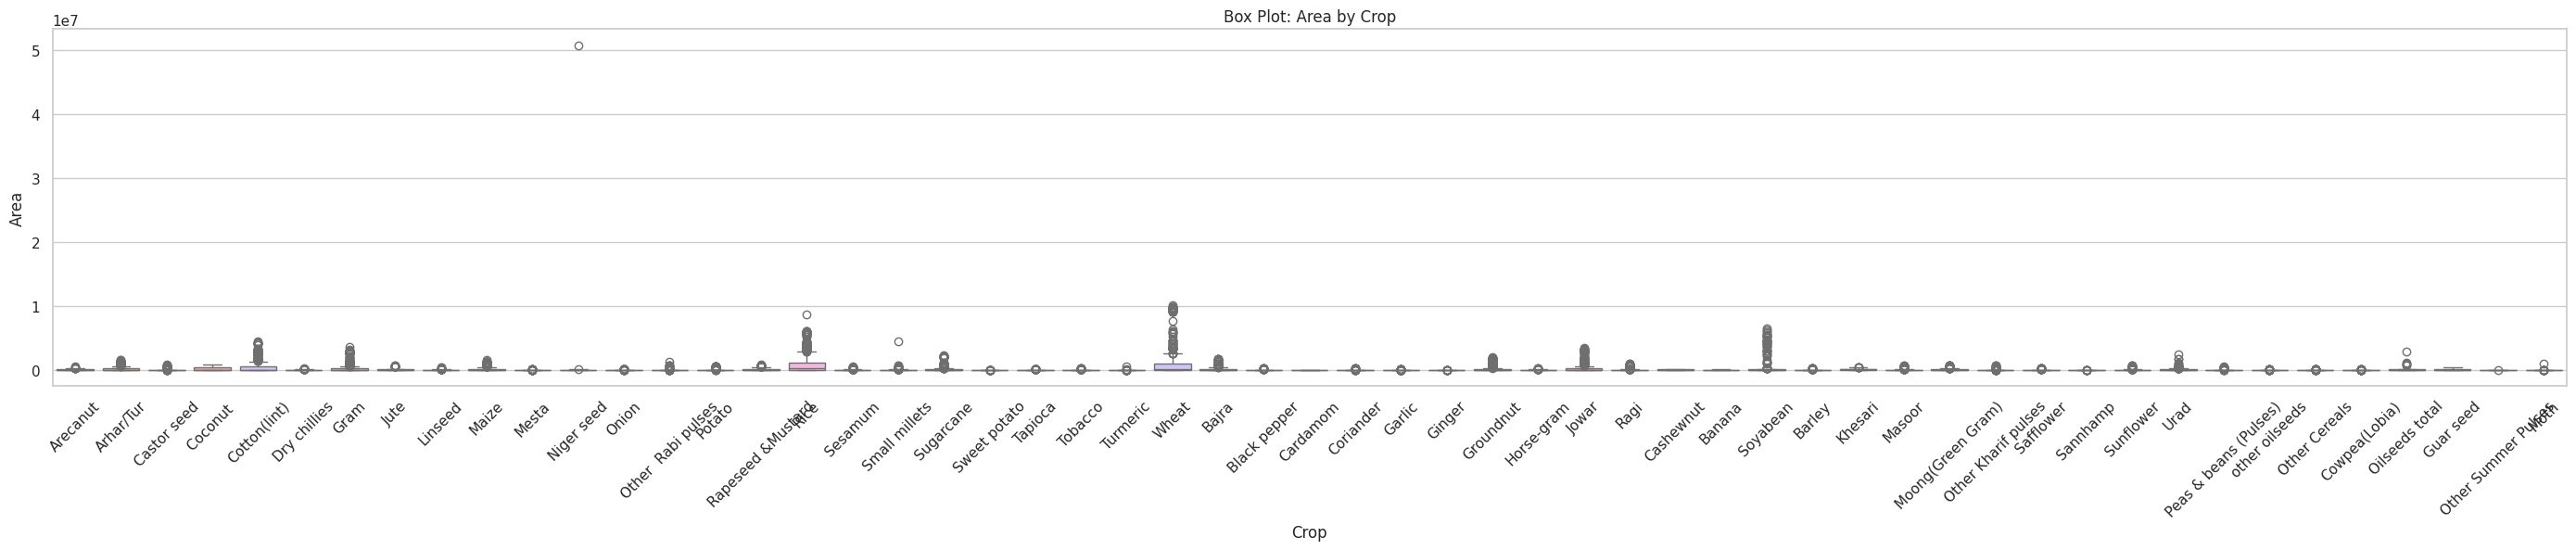


⚠️ No 'Year' or time column found for line plot — skipped.


In [ ]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("/content/crop_yield_reduced.csv")

# ---------------------------------------------
# Select numeric and categorical columns
# ---------------------------------------------
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

print("Numeric Columns:", list(numeric_cols))
print("Categorical Columns:", list(cat_cols))

# For demonstration, pick representative columns (update names if needed)
numeric_x = numeric_cols[0] if len(numeric_cols) > 0 else None
numeric_y = numeric_cols[1] if len(numeric_cols) > 1 else None
categorical_col = cat_cols[0] if len(cat_cols) > 0 else None

# Set seaborn style
sns.set(style="whitegrid")

# ---------------------------------------------
# 1️⃣ BAR CHART — Compare categorical values
# ---------------------------------------------
if categorical_col and numeric_y:
    plt.figure(figsize=(35,5))
    sns.barplot(data=df, x=categorical_col, y=numeric_y, palette="viridis")
    plt.title(f"Bar Chart: {numeric_y} by {categorical_col}")
    plt.xticks(rotation=45)
    plt.show()

# ---------------------------------------------
# 2️⃣ HISTOGRAM — Distribution of numeric feature
# ---------------------------------------------
if numeric_x:
    plt.figure(figsize=(12,5))
    plt.hist(df[numeric_x], bins=20, color='skyblue', edgecolor='black')
    plt.title(f"Histogram of {numeric_x}")
    plt.xlabel(numeric_x)
    plt.ylabel("Frequency")
    plt.show()

# ---------------------------------------------
# 3️⃣ SCATTER PLOT — Relationship between two numeric features
# ---------------------------------------------
if numeric_x and numeric_y:
    plt.figure(figsize=(20,3))
    sns.scatterplot(data=df, x=numeric_x, y=numeric_y, hue=categorical_col, palette="cool", s=50)
    plt.title(f"Scatter Plot: {numeric_x} vs {numeric_y}")
    plt.show()

# ---------------------------------------------
# 4️⃣ BOX PLOT — Detect outliers and spread
# ---------------------------------------------
if categorical_col and numeric_y:
    plt.figure(figsize=(35,5))
    sns.boxplot(data=df, x=categorical_col, y=numeric_y, palette="pastel")
    plt.title(f"Box Plot: {numeric_y} by {categorical_col}")
    plt.xticks(rotation=45)
    plt.show()

# ---------------------------------------------
# 5️⃣ LINE PLOT — Trend over time (if date/time or sequential index available)
# ---------------------------------------------
# If dataset has a 'Year' or 'Date' column
if 'Year' in df.columns and numeric_y:
    plt.figure(figsize=(8,5))
    sns.lineplot(data=df, x='Year', y=numeric_y, marker='o', color='teal')
    plt.title(f"Trend of {numeric_y} over Years")
    plt.show()
else:
    print("\n⚠️ No 'Year' or time column found for line plot — skipped.")


Numeric Columns: ['Crop_Year', 'Area', 'Production', 'Annual_Rainfall', 'Yield']
Categorical Columns: ['Crop', 'Season', 'State']


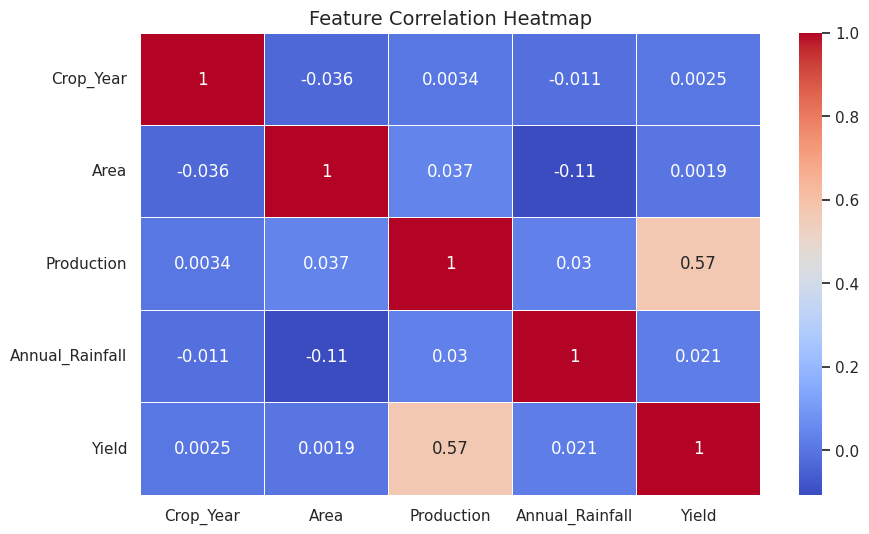

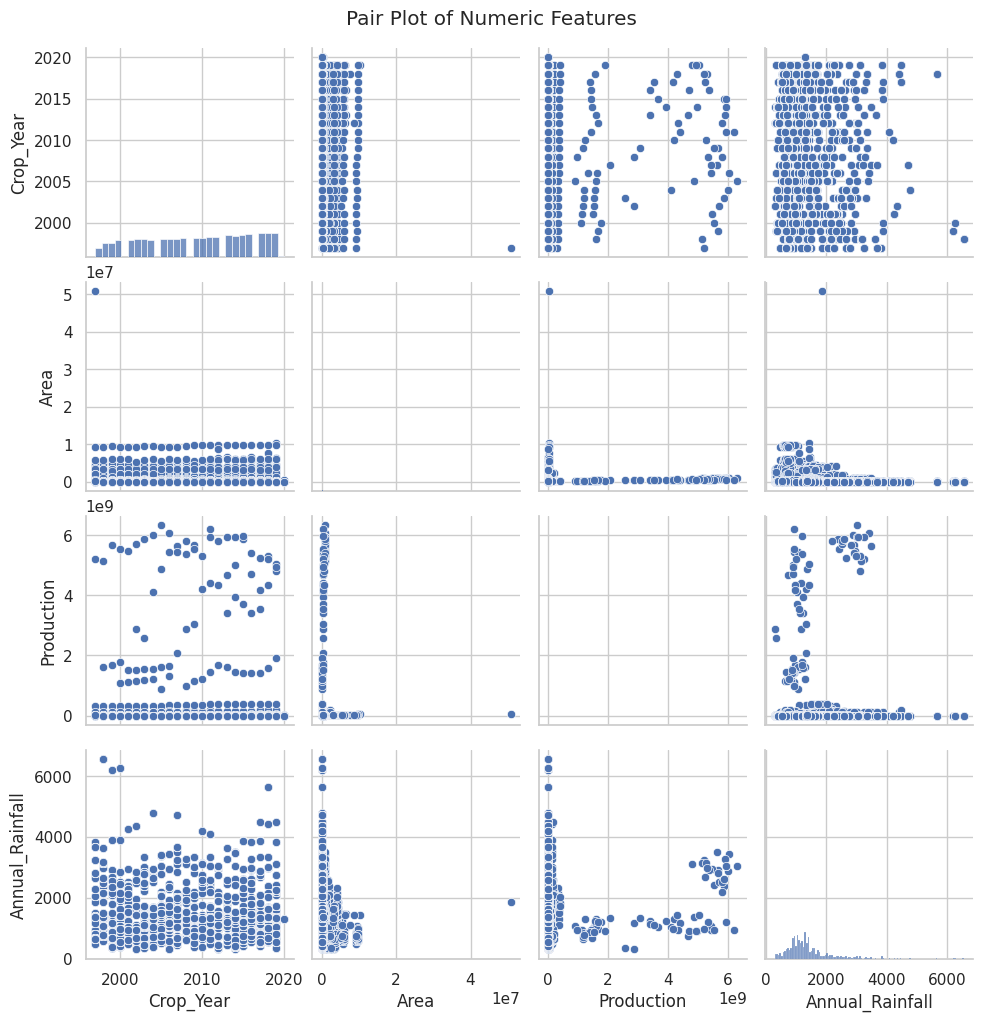

/tmp/ipython-input-642638653.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x=cat_col, y=y_col, palette="muted")


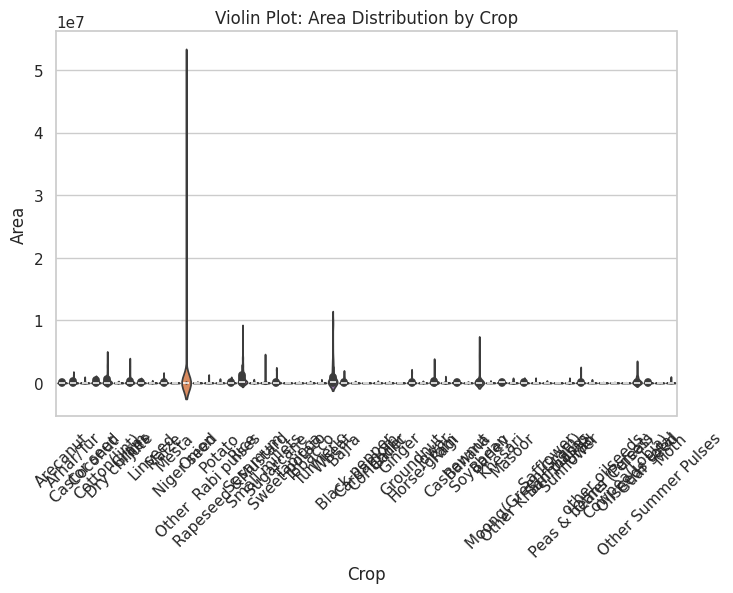

/tmp/ipython-input-642638653.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(data=df, x=cat_col, y=y_col, palette="cool", size=5)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 99.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 99.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 98.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/c

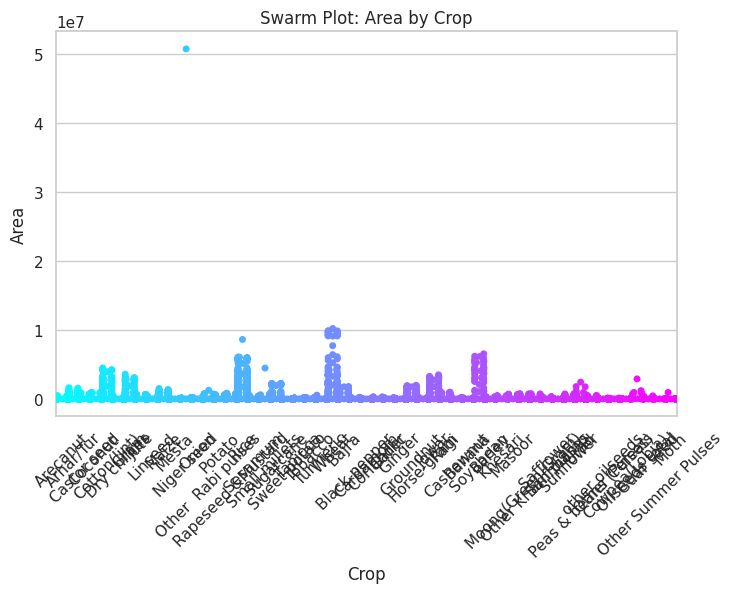

In [ ]:
# Install required libraries (if not installed)
!pip install seaborn matplotlib plotly --quiet

# Import libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
from mpl_toolkits.mplot3d import Axes3D

# Load dataset
df = pd.read_csv("/content/crop_yield_reduced.csv")

# Identify numeric and categorical columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

sns.set(style="whitegrid")

print("Numeric Columns:", list(numeric_cols))
print("Categorical Columns:", list(cat_cols))

# Example column selection (customize as needed)
x_col = numeric_cols[0] if len(numeric_cols) > 0 else None
y_col = numeric_cols[1] if len(numeric_cols) > 1 else None
z_col = numeric_cols[2] if len(numeric_cols) > 2 else None
cat_col = cat_cols[0] if len(cat_cols) > 0 else None

# ------------------------------------------------
# 1️⃣ HEATMAP — Show correlations or patterns
# ------------------------------------------------
plt.figure(figsize=(10,6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Feature Correlation Heatmap", fontsize=14)
plt.show()

# ------------------------------------------------
# 2️⃣ PAIR PLOT — Relationships among multiple features
# ------------------------------------------------
sns.pairplot(df[numeric_cols[:4]])  # limit to first few for readability
plt.suptitle("Pair Plot of Numeric Features", y=1.02)
plt.show()

# ------------------------------------------------
# 3️⃣ VIOLIN PLOT — Distribution + density + box
# ------------------------------------------------
if cat_col and y_col:
    plt.figure(figsize=(8,5))
    sns.violinplot(data=df, x=cat_col, y=y_col, palette="muted")
    plt.title(f"Violin Plot: {y_col} Distribution by {cat_col}")
    plt.xticks(rotation=45)
    plt.show()

# ------------------------------------------------
# 4️⃣ SWARM PLOT — Distribution by category
# ------------------------------------------------
if cat_col and y_col:
    plt.figure(figsize=(8,5))
    sns.swarmplot(data=df, x=cat_col, y=y_col, palette="cool", size=5)
    plt.title(f"Swarm Plot: {y_col} by {cat_col}")
    plt.xticks(rotation=45)
    plt.show()

# ------------------------------------------------
# 5️⃣ BUBBLE / 3D SCATTER PLOT — Multi-dimensional visualization
# ------------------------------------------------
if x_col and y_col and z_col:
    fig = px.scatter_3d(df, x=x_col, y=y_col, z=z_col,
                        color=cat_col if cat_col else x_col,
                        size=df[numeric_cols[0]].abs(),
                        opacity=0.7, title="3D Scatter Plot (Bubble Chart)")
    fig.show()
else:
    print("\n⚠️ Not enough numeric columns for 3D Scatter Plot — skipped.")


<Figure size 800x600 with 0 Axes>

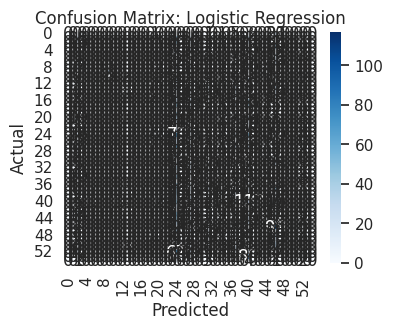

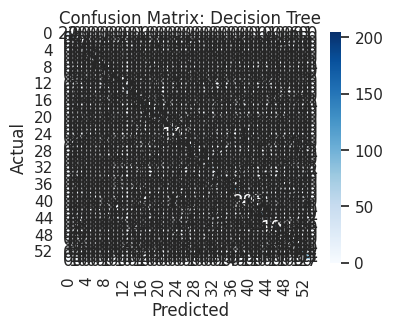

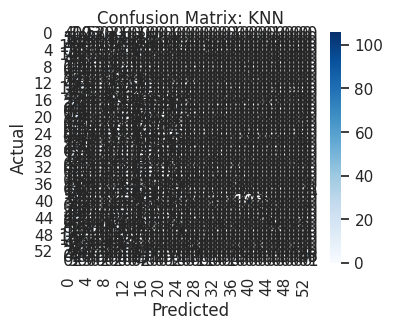

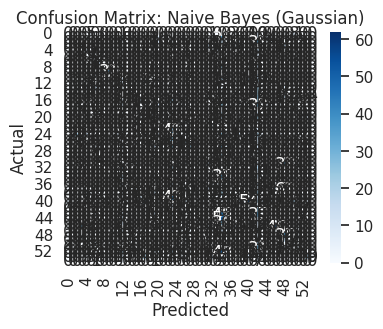

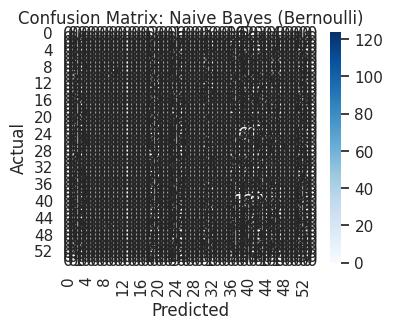

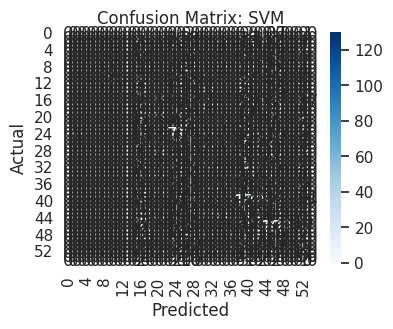


⚠️ ROC Curve plot skipped: Applicable only for binary classification.

✅ Model Performance Summary:

                     Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
1            Decision Tree     0.638      0.640   0.638     0.638    0.808
5                      SVM     0.139      0.092   0.139     0.086    0.832
3   Naive Bayes (Gaussian)     0.129      0.199   0.129     0.123    0.829
2                      KNN     0.099      0.168   0.099     0.108    0.555
0      Logistic Regression     0.097      0.049   0.097     0.048    0.778
4  Naive Bayes (Bernoulli)     0.090      0.063   0.090     0.054    0.729


In [ ]:
# 📦 Install libraries (if needed)
!pip install scikit-learn matplotlib seaborn --quiet

# 🧠 Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve, auc
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB, BernoulliNB
from sklearn.svm import SVC

# ------------------------------------------------------------
# 1⽠ Load and prepare dataset
# ------------------------------------------------------------
df = pd.read_csv("/content/crop_yield_reduced.csv")

# 🧩 Replace with your actual target column
target_col = "Crop"   # 👈 change this to your classification target (e.g., 'Crop', 'Type', etc.)

# Label Encoding for categorical columns
df_encoded = df.copy()
for col in df_encoded.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])

# Split features and target
X = df_encoded.drop(columns=[target_col])
y = df_encoded[target_col]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale features for models sensitive to magnitude
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ------------------------------------------------------------
# 2⽠ Define Models
# ------------------------------------------------------------
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Naive Bayes (Gaussian)": GaussianNB(),
    "Naive Bayes (Bernoulli)": BernoulliNB(),
    "SVM": SVC(kernel='rbf', probability=True, random_state=42)
}

# ------------------------------------------------------------
# 3⽠ Train & Evaluate
# ------------------------------------------------------------
results = []

plt.figure(figsize=(8,6))
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    # Check if the model has predict_proba before calling it
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)
    else:
        y_prob = None

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    # ROC–AUC (only if binary or probabilistic)
    try:
        if y_prob is not None:
            roc_auc = roc_auc_score(y_test, y_prob, multi_class='ovr')
        else:
            roc_auc = np.nan
    except Exception as e:
        roc_auc = np.nan

    results.append([name, acc, prec, rec, f1, roc_auc])

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix: {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # ROC Curve (if applicable) - only for binary classification currently
    if y_prob is not None and len(np.unique(y_test)) == 2:
        # For binary classification, y_prob needs to be the probability of the positive class
        fpr, tpr, _ = roc_curve(y_test, y_prob[:, 1])
        roc_auc_val = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc_val:.2f})")

# ------------------------------------------------------------
# 4⽠ ROC Curves Plot (Binary only)
# ------------------------------------------------------------
# Only plot ROC curves if it's a binary classification problem
if len(np.unique(y_test)) == 2:
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curves for All Models')
    plt.legend()
    plt.show()
else:
    print("\n⚠️ ROC Curve plot skipped: Applicable only for binary classification.")


# ------------------------------------------------------------
# 5⽠ Display Results
# ------------------------------------------------------------
results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"])
print("\n✅ Model Performance Summary:\n")
print(results_df.sort_values(by="Accuracy", ascending=False).round(3))

<Figure size 800x600 with 0 Axes>

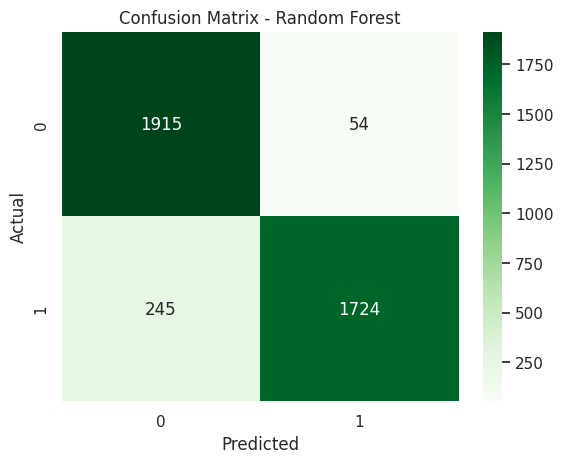

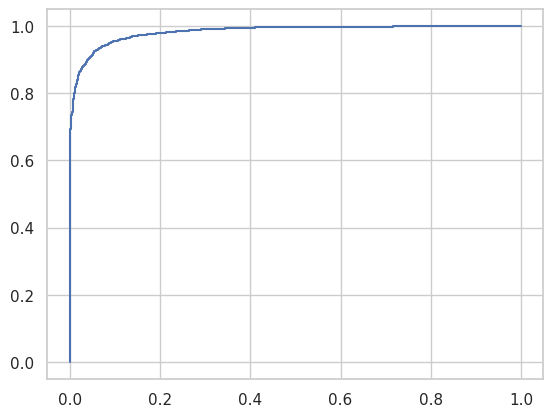

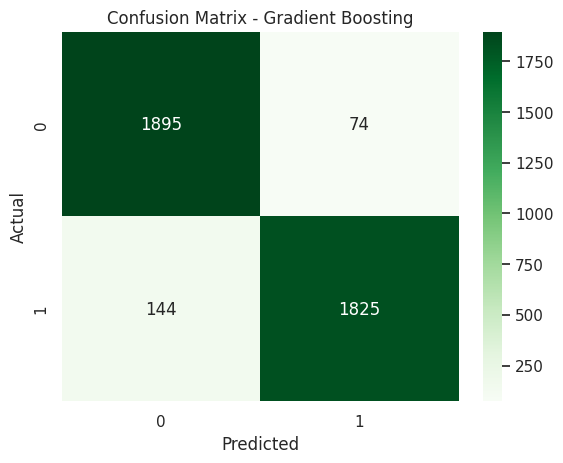

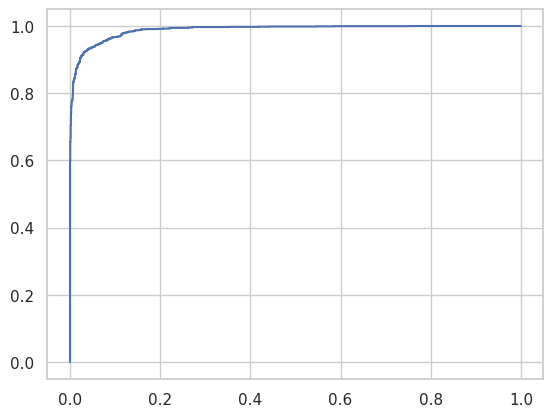

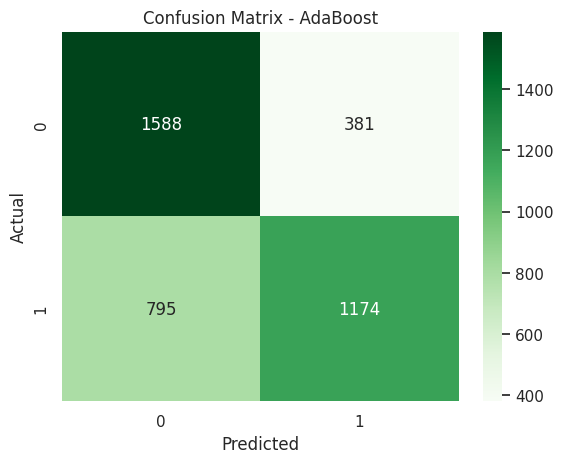

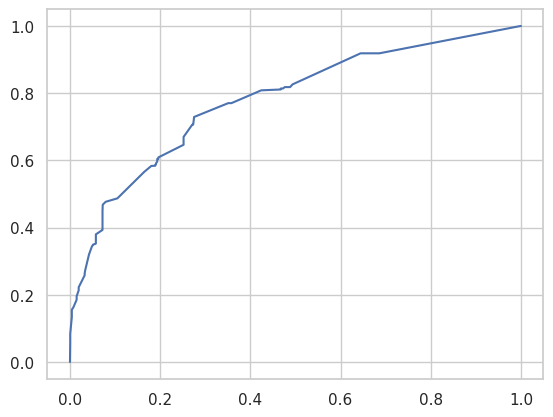

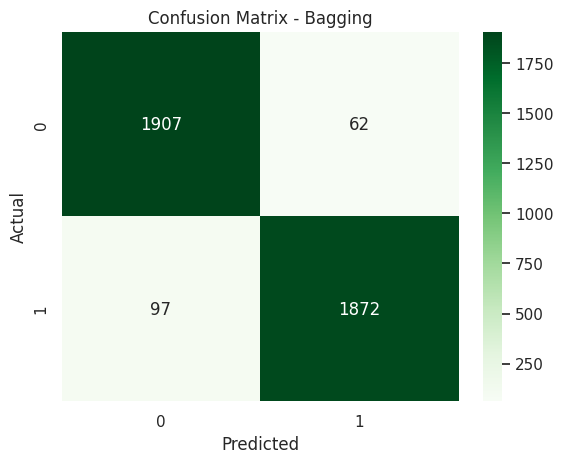

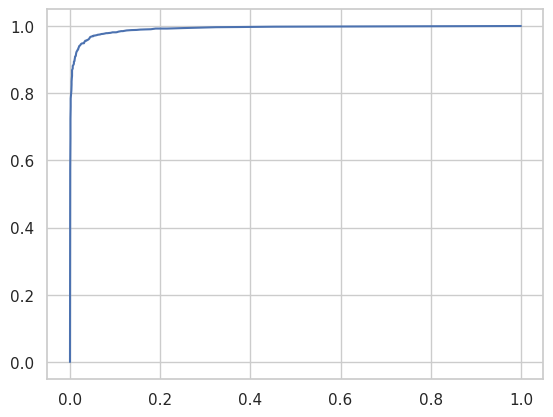

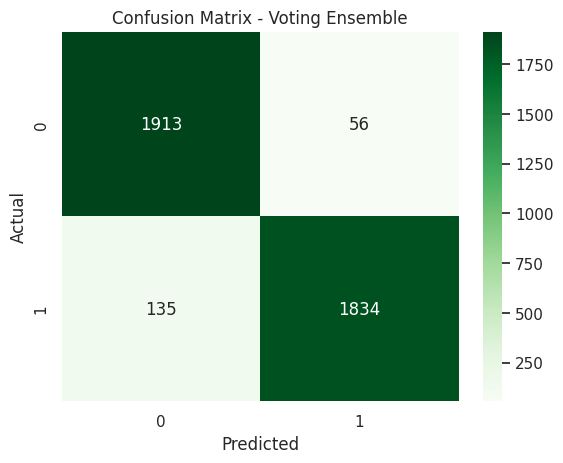


📊 Ensemble Model Performance Summary:

               Model  Accuracy  Precision    Recall  F1-Score       AUC
3            Bagging  0.959624   0.967942  0.950736  0.959262  0.992010
4    Voting Ensemble  0.951498   0.970370  0.931437  0.950505  0.989339
1  Gradient Boosting  0.944642   0.961032  0.926866  0.943640  0.989018
0      Random Forest  0.924073   0.969629  0.875571  0.920203  0.983121
2           AdaBoost  0.701371   0.754984  0.596242  0.666288  0.778660


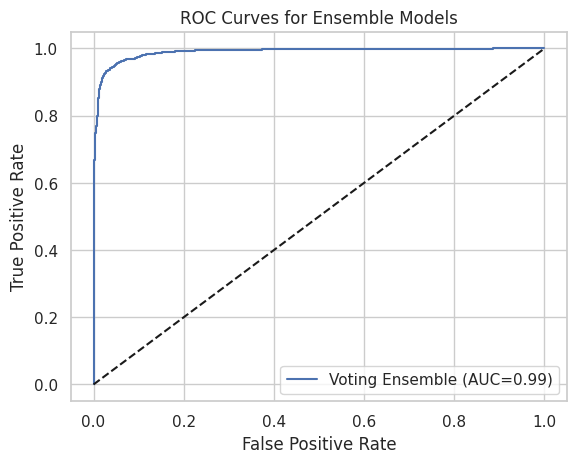

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier,
    BaggingClassifier,
    VotingClassifier
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, roc_curve
)
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------------------
# 1️⃣ Load and Prepare Dataset
# -----------------------------------------
df = pd.read_csv("crop_yield.csv")

# Binary target: High (1) if Yield > median, else Low (0)
df = df.dropna(subset=["Yield"])
median_yield = df["Yield"].median()
df["Yield_Class"] = (df["Yield"] > median_yield).astype(int)

# Encode categorical features
for col in df.select_dtypes(include="object").columns:
    df[col] = LabelEncoder().fit_transform(df[col].astype(str))

# Split features and target
X = df.drop(["Yield", "Yield_Class"], axis=1)
y = df["Yield_Class"]

# Standard scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# -----------------------------------------
# 2️⃣ Define Ensemble Models
# -----------------------------------------
models = {
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=150, learning_rate=0.1, random_state=42),
    "AdaBoost": AdaBoostClassifier(n_estimators=150, learning_rate=0.1, random_state=42),
    "Bagging": BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=100, random_state=42),
}

# Voting Classifier combines multiple models
voting_model = VotingClassifier(
    estimators=[
        ("rf", models["Random Forest"]),
        ("gb", models["Gradient Boosting"]),
        ("ada", models["AdaBoost"]),
        ("bag", models["Bagging"]),
        ("lr", LogisticRegression(solver="liblinear")),
    ],
    voting="soft"
)
models["Voting Ensemble"] = voting_model

# -----------------------------------------
# 3️⃣ Train, Predict, and Evaluate
# -----------------------------------------
results = []
plt.figure(figsize=(8, 6))

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Get probabilities for AUC/ROC
    y_proba = (
        model.predict_proba(X_test)[:, 1]
        if hasattr(model, "predict_proba")
        else (model.decision_function(X_test) - model.decision_function(X_test).min()) /
             (model.decision_function(X_test).max() - model.decision_function(X_test).min() + 1e-8)
    )

    # Compute metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)

    results.append([name, acc, prec, rec, f1, auc])

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure()
    sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.2f})")

# -----------------------------------------
# 4️⃣ Display Evaluation Table
# -----------------------------------------
results_df = pd.DataFrame(
    results, columns=["Model", "Accuracy", "Precision", "Recall", "F1-Score", "AUC"]
)
print("\n📊 Ensemble Model Performance Summary:\n")
print(results_df.sort_values(by="Accuracy", ascending=False))

# -----------------------------------------
# 5️⃣ Combined ROC Curve Plot
# -----------------------------------------
plt.plot([0, 1], [0, 1], "k--")
plt.title("ROC Curves for Ensemble Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

<Figure size 800x600 with 0 Axes>

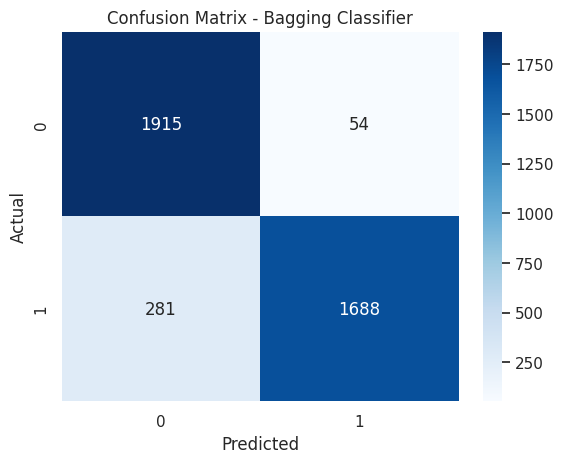

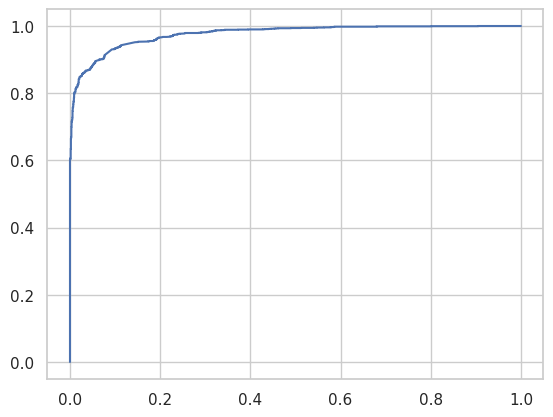

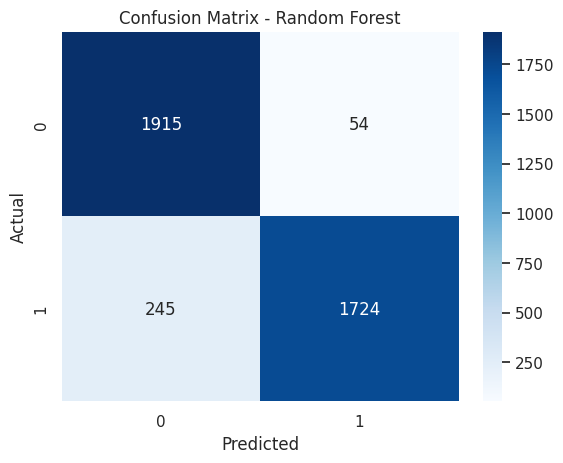

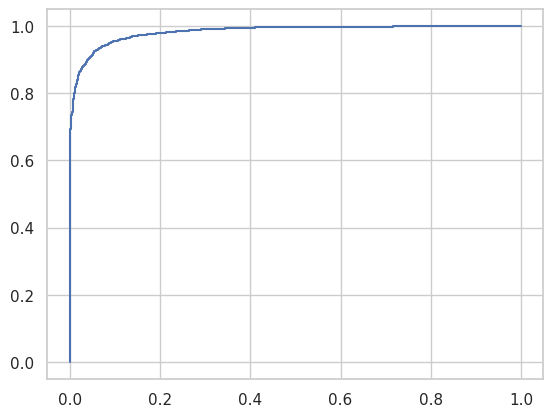

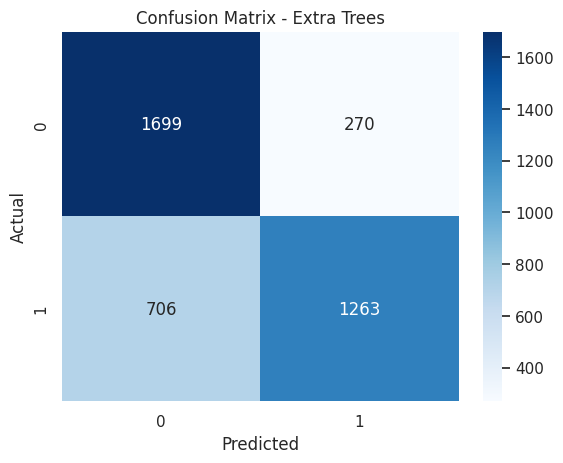


📊 Bagging-Based Model Performance Summary:

                Model  Accuracy  Precision    Recall  F1-Score       AUC
1       Random Forest  0.924073   0.969629  0.875571  0.920203  0.983121
0  Bagging Classifier  0.914931   0.969001  0.857288  0.909728  0.976474
2         Extra Trees  0.752158   0.823875  0.641442  0.721302  0.861248


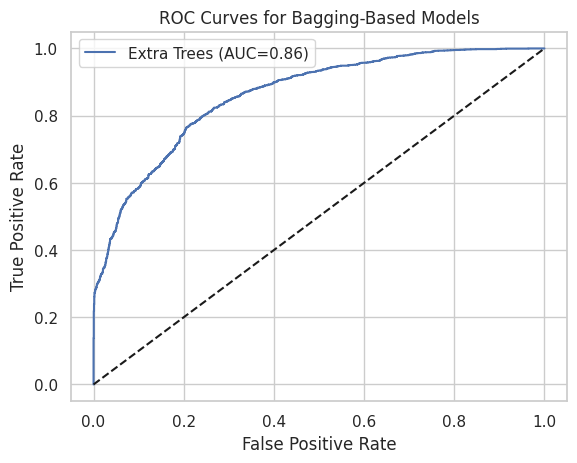

In [ ]:
# ==========================================
# 🌾 Bagging-Based Ensemble Methods for Crop Yield Classification
# ==========================================
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import (
    BaggingClassifier,
    RandomForestClassifier,
    ExtraTreesClassifier
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, roc_curve
)
import seaborn as sns
import matplotlib.pyplot as plt

# -----------------------------------------
# 1️⃣ Load and Prepare Dataset
# -----------------------------------------
df = pd.read_csv("crop_yield.csv")

# Drop missing target values
df = df.dropna(subset=["Yield"])

# Create binary target (High yield = 1, Low yield = 0)
median_yield = df["Yield"].median()
df["Yield_Class"] = (df["Yield"] > median_yield).astype(int)

# Encode categorical features
for col in df.select_dtypes(include="object").columns:
    df[col] = LabelEncoder().fit_transform(df[col].astype(str))

# Define X and y
X = df.drop(["Yield", "Yield_Class"], axis=1)
y = df["Yield_Class"]

# Scale numerical features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# -----------------------------------------
# 2️⃣ Define Bagging Models
# -----------------------------------------
models = {
    "Bagging Classifier": BaggingClassifier(
        estimator=DecisionTreeClassifier(max_depth=8),
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    ),
    "Extra Trees": ExtraTreesClassifier(
        n_estimators=200,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    ),
}

# -----------------------------------------
# 3️⃣ Train, Predict, and Evaluate Models
# -----------------------------------------
results = []
plt.figure(figsize=(8, 6))

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    # Compute Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    results.append([name, acc, prec, rec, f1, auc])

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure()
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.2f})")

# -----------------------------------------
# 4️⃣ Performance Summary
# -----------------------------------------
results_df = pd.DataFrame(
    results, columns=["Model", "Accuracy", "Precision", "Recall", "F1-Score", "AUC"]
)
print("\n📊 Bagging-Based Model Performance Summary:\n")
print(results_df.sort_values(by="Accuracy", ascending=False))

# -----------------------------------------
# 5️⃣ ROC Curves for All Models
# -----------------------------------------
plt.plot([0, 1], [0, 1], "k--")
plt.title("ROC Curves for Bagging-Based Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()


In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 12.2 MB/s eta 0:00:00


In [ ]:
!pip install lightgbm xgboost


🔹 Training AdaBoost...


<Figure size 800x600 with 0 Axes>

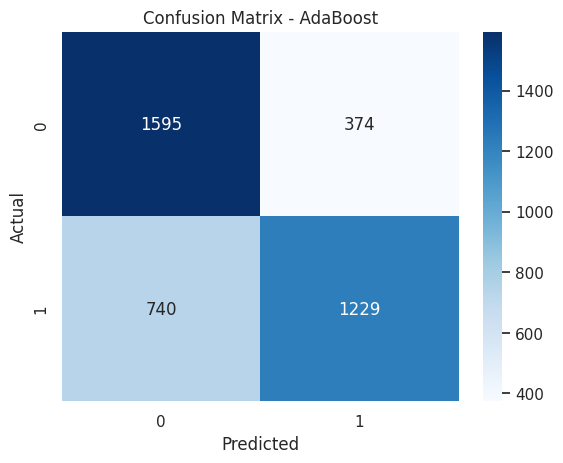


🔹 Training Gradient Boosting...


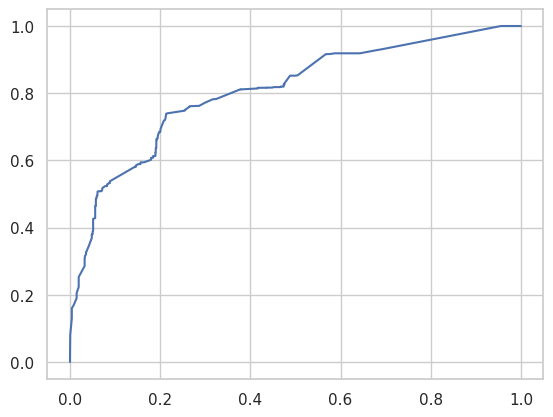

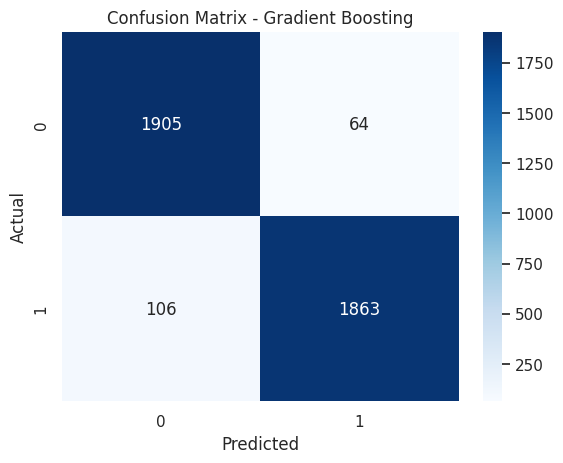


🔹 Training XGBoost...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning:

[09:45:24] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.




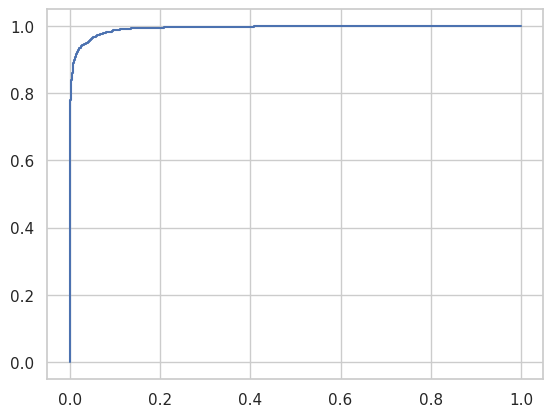

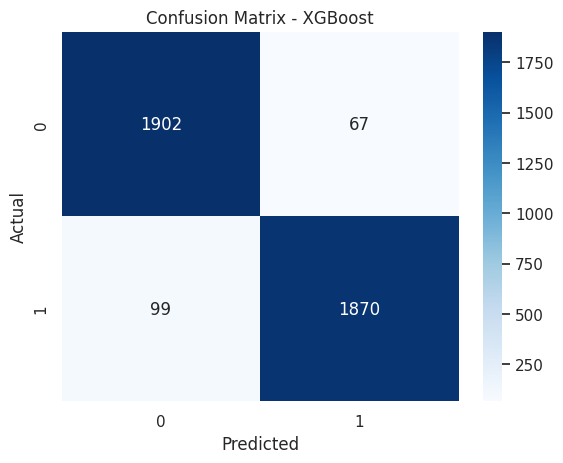


🔹 Training LightGBM...
[LightGBM] [Info] Number of positive: 7875, number of negative: 7876
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000661 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1393
[LightGBM] [Info] Number of data points in the train set: 15751, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499968 -> initscore=-0.000127
[LightGBM] [Info] Start training from score -0.000127


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LGBMClassifier was fitted with feature names

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LGBMClassifier was fitted with feature names



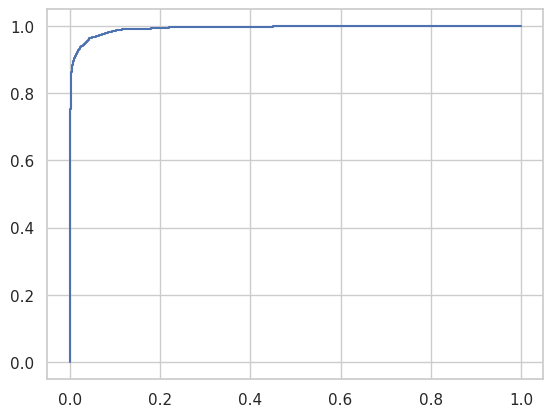

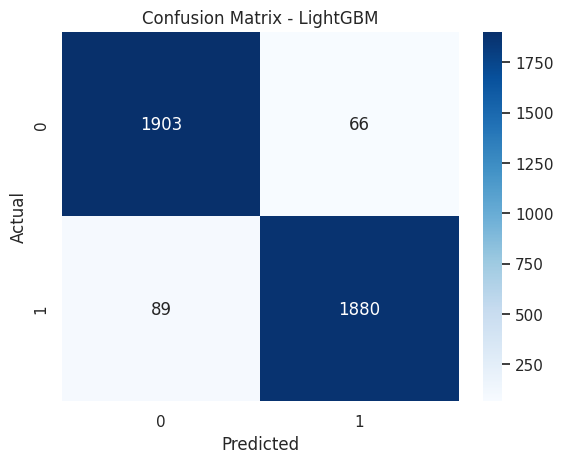


🔹 Training CatBoost...


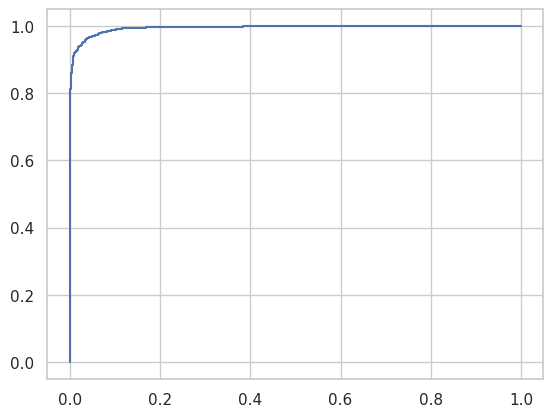

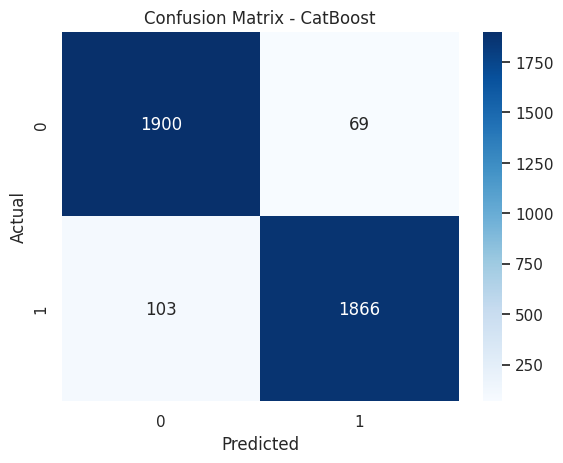


📊 Boosting Model Performance Summary:

               Model  Accuracy  Precision    Recall  F1-Score       AUC
3           LightGBM  0.960640   0.966084  0.954799  0.960409  0.994540
2            XGBoost  0.957847   0.965410  0.949721  0.957501  0.993483
1  Gradient Boosting  0.956831   0.966788  0.946166  0.956366  0.993547
4           CatBoost  0.956323   0.964341  0.947689  0.955943  0.993207
0           AdaBoost  0.717115   0.766687  0.624175  0.688130  0.807112


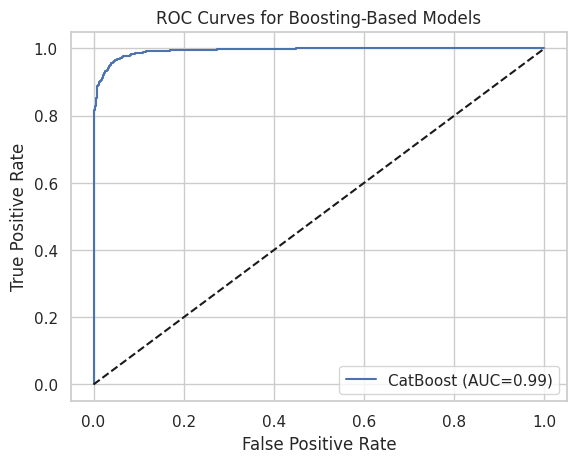

In [ ]:
# ==========================================
# 🌾 Boosting-Based Ensemble Models for Crop Yield Prediction
# ==========================================
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, roc_curve
)
import seaborn as sns
import matplotlib.pyplot as plt

# External boosting libraries
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# -----------------------------------------
# 1️⃣ Load and Prepare Dataset
# -----------------------------------------
df = pd.read_csv("crop_yield.csv")

# Drop missing yield values
df = df.dropna(subset=["Yield"])

# Create binary classification target
median_yield = df["Yield"].median()
df["Yield_Class"] = (df["Yield"] > median_yield).astype(int)

# Encode categorical features
for col in df.select_dtypes(include="object").columns:
    df[col] = LabelEncoder().fit_transform(df[col].astype(str))

# Define features and target
X = df.drop(["Yield", "Yield_Class"], axis=1)
y = df["Yield_Class"]

# Scale numeric data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# -----------------------------------------
# 2️⃣ Define Boosting Models
# -----------------------------------------
models = {
    "AdaBoost": AdaBoostClassifier(
        n_estimators=200, learning_rate=0.1, random_state=42
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200, learning_rate=0.1, max_depth=5, random_state=42
    ),
    "XGBoost": XGBClassifier(
        n_estimators=300, learning_rate=0.1, max_depth=6, random_state=42,
        eval_metric="logloss", use_label_encoder=False
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=300, learning_rate=0.1, max_depth=-1, random_state=42
    ),
    "CatBoost": CatBoostClassifier(
        iterations=300, learning_rate=0.1, depth=6, verbose=0, random_state=42
    )
}

# -----------------------------------------
# 3️⃣ Train, Predict, and Evaluate
# -----------------------------------------
results = []
plt.figure(figsize=(8, 6))

for name, model in models.items():
    print(f"\n🔹 Training {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    # Compute metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    results.append([name, acc, prec, rec, f1, auc])

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure()
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.2f})")

# -----------------------------------------
# 4️⃣ Results Summary
# -----------------------------------------
results_df = pd.DataFrame(
    results, columns=["Model", "Accuracy", "Precision", "Recall", "F1-Score", "AUC"]
)

print("\n📊 Boosting Model Performance Summary:\n")
print(results_df.sort_values(by="Accuracy", ascending=False))

# -----------------------------------------
# 5️⃣ Combined ROC Curve
# -----------------------------------------
plt.plot([0, 1], [0, 1], "k--")
plt.title("ROC Curves for Boosting-Based Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()


In [ ]:
# ==========================================
# Ensemble Models: Stacking & Voting
# ==========================================
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import StackingClassifier, VotingClassifier

# ==========================================
# Step 1: Load and preprocess dataset
# ==========================================
df = pd.read_csv("/content/crop_yield.csv")   # update path if needed

# Drop missing target values
df = df.dropna(subset=['Yield'])

# Binary classification target based on median Yield
median_yield = df['Yield'].median()
df['Yield_Class'] = (df['Yield'] > median_yield).astype(int)

# Encode categorical features
for col in df.select_dtypes(include=['object']).columns:
    df[col] = LabelEncoder().fit_transform(df[col].astype(str))

# Define features and target
X = df.drop(['Yield', 'Yield_Class'], axis=1)
y = df['Yield_Class']

# Standard scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# ==========================================
# Step 2: Define Base Models
# ==========================================
base_models = [
    ('lr', LogisticRegression(solver='liblinear')),
    ('dt', DecisionTreeClassifier(max_depth=5, random_state=42)),
    ('knn', KNeighborsClassifier(n_neighbors=5)),
    ('nb', GaussianNB()),
    ('svm', SVC(probability=True, kernel='rbf'))
]

# ==========================================
# Step 3: Stacking Classifier
# ==========================================
stack_model = StackingClassifier(
    estimators=base_models,
    final_estimator=LogisticRegression(),
    cv=5,
    n_jobs=-1
)

stack_model.fit(X_train, y_train)
y_pred_stack = stack_model.predict(X_test)

# ==========================================
# Step 4: Voting Classifier (Soft Voting)
# ==========================================
vote_model = VotingClassifier(
    estimators=base_models,
    voting='soft',
    n_jobs=-1
)

vote_model.fit(X_train, y_train)
y_pred_vote = vote_model.predict(X_test)

# ==========================================
# Step 5: Evaluation Function
# ==========================================
def evaluate_model(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)

    print(f"\n{name} Results:")
    print(f"Accuracy:  {acc:.3f}")
    print(f"Precision: {prec:.3f}")
    print(f"Recall:    {rec:.3f}")
    print(f"F1-Score:  {f1:.3f}")
    print("Confusion Matrix:\n", cm)
    print("-" * 50)

# ==========================================
# Step 6: Display Results
# ==========================================
evaluate_model("Stacking Classifier", y_test, y_pred_stack)
evaluate_model("Voting Classifier", y_test, y_pred_vote)



Stacking Classifier Results:
Accuracy:  0.821
Precision: 0.844
Recall:    0.788
F1-Score:  0.815
Confusion Matrix:
 [[1682  287]
 [ 417 1552]]
--------------------------------------------------

Voting Classifier Results:
Accuracy:  0.747
Precision: 0.908
Recall:    0.549
F1-Score:  0.684
Confusion Matrix:
 [[1860  109]
 [ 889 1080]]
--------------------------------------------------


**FNN**

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



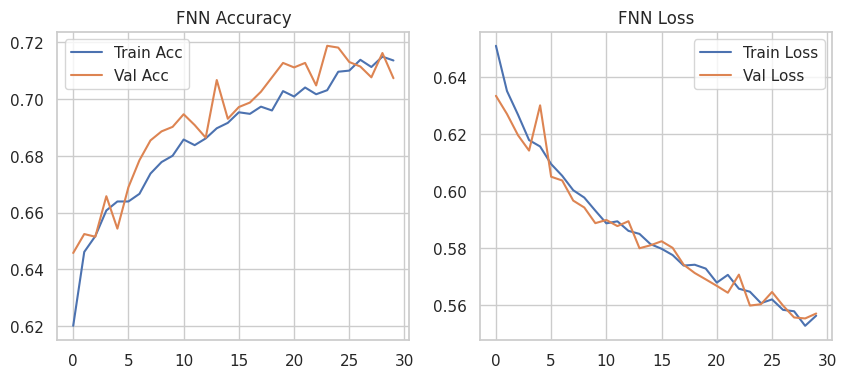

124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Accuracy: 0.725, Precision: 0.725, Recall: 0.723, F1: 0.724

Confusion Matrix:
 [[1430  539]
 [ 545 1424]]


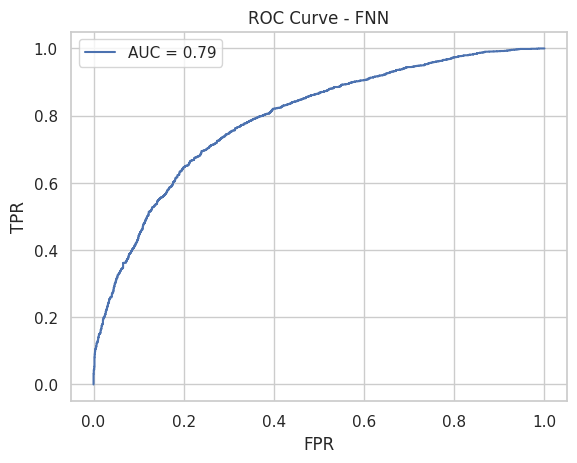

In [ ]:
# ==========================
# Feedforward Neural Network
# ==========================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical

# Load dataset
df = pd.read_csv("/content/crop_yield.csv")

# Drop missing yield values
df = df.dropna(subset=["Yield"])

# Create binary classification target (High yield = 1, Low yield = 0)
median_yield = df["Yield"].median()
df["Yield_Class"] = (df["Yield"] > median_yield).astype(int)

# Encode categorical features (if any remain after dropping Yield and Yield_Class)
for col in df.select_dtypes(include=["object"]).columns:
    df[col] = LabelEncoder().fit_transform(df[col].astype(str))

# Define features and target
X = df.drop(["Yield", "Yield_Class"], axis=1)
y = df["Yield_Class"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

# MLP / DNN Model
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history = model.fit(X_train, y_train, validation_split=0.2, epochs=30, batch_size=32, verbose=0)

# Plot accuracy and loss
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend(); plt.title("FNN Accuracy")

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend(); plt.title("FNN Loss")
plt.show()

# Evaluation
y_pred_prob = model.predict(X_test).ravel()
y_pred = (y_pred_prob > 0.5).astype(int)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print(f"Accuracy: {acc:.3f}, Precision: {prec:.3f}, Recall: {rec:.3f}, F1: {f1:.3f}")

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

# ROC-AUC
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
plt.xlabel('FPR'); plt.ylabel('TPR'); plt.legend(); plt.title('ROC Curve - FNN')
plt.show()

**CNN**

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 49s 53ms/step - accuracy: 0.8806 - loss: 0.3983 - val_accuracy: 0.9860 - val_loss: 0.0484
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 41s 49ms/step - accuracy: 0.9855 - loss: 0.0501 - val_accuracy: 0.9885 - val_loss: 0.0447
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 42s 49ms/step - accuracy: 0.9906 - loss: 0.0309 - val_accuracy: 0.9895 - val_loss: 0.0347
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 41s 48ms/step - accuracy: 0.9930 - loss: 0.0226 - val_accuracy: 0.9882 - val_loss: 0.0400
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 42s 50ms/step - accuracy: 0.9951 - loss: 0.0166 - val_accuracy: 0.9912 - val_loss: 0.0327


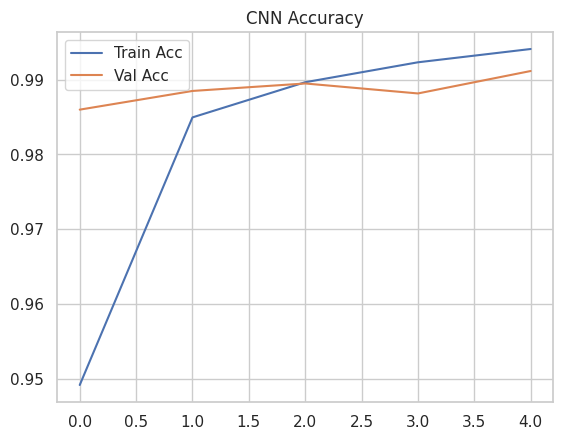

Test Accuracy: 0.991


In [ ]:
# ==========================
# CNN Example (MNIST)
# ==========================
from tensorflow.keras.datasets import mnist
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten

(X_train, y_train), (X_test, y_test) = mnist.load_data()
X_train = X_train.reshape(-1, 28, 28, 1).astype('float32') / 255
X_test = X_test.reshape(-1, 28, 28, 1).astype('float32') / 255
y_train_cat = to_categorical(y_train)
y_test_cat = to_categorical(y_test)

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history = model.fit(X_train, y_train_cat, validation_split=0.1, epochs=5, batch_size=64, verbose=1)

# Accuracy and Loss Plots
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend(); plt.title('CNN Accuracy'); plt.show()

# Evaluation
loss, acc = model.evaluate(X_test, y_test_cat, verbose=0)
print(f"Test Accuracy: {acc:.3f}")


**RNN**

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 99s 306ms/step - accuracy: 0.7108 - loss: 0.5363 - val_accuracy: 0.8436 - val_loss: 0.3555
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 76s 244ms/step - accuracy: 0.9057 - loss: 0.2409 - val_accuracy: 0.8532 - val_loss: 0.3709
Epoch 3/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 81s 241ms/step - accuracy: 0.9336 - loss: 0.1780 - val_accuracy: 0.8714 - val_loss: 0.3430


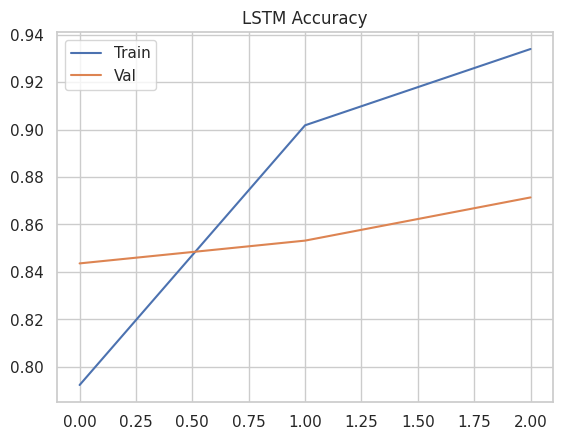

782/782 ━━━━━━━━━━━━━━━━━━━━ 26s 34ms/step - accuracy: 0.8569 - loss: 0.3714
LSTM Test Accuracy: 0.859


In [ ]:
# ==========================
# LSTM Example (IMDB Sentiment)
# ==========================
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Embedding, LSTM

max_features = 10000
maxlen = 200

(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=max_features)
X_train = pad_sequences(X_train, maxlen=maxlen)
X_test = pad_sequences(X_test, maxlen=maxlen)

model = Sequential([
    Embedding(max_features, 128),
    LSTM(64),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history = model.fit(X_train, y_train, validation_split=0.2, epochs=3, batch_size=64)

# Accuracy Plot
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.legend(); plt.title('LSTM Accuracy'); plt.show()

# Evaluate
loss, acc = model.evaluate(X_test, y_test)
print(f"LSTM Test Accuracy: {acc:.3f}")


**Transformer-Based Model**

In [ ]:
!pip install transformers datasets -q

In [ ]:
!pip uninstall -y transformers tokenizers huggingface_hub tensorflow tf-keras
!pip install -U transformers==4.43.3 tensorflow==2.19.0 tf-keras==2.19.0 huggingface_hub==0.24.6


Found existing installation: transformers 4.43.3
Uninstalling transformers-4.43.3:
  Successfully uninstalled transformers-4.43.3
Found existing installation: tokenizers 0.19.1
Uninstalling tokenizers-0.19.1:
  Successfully uninstalled tokenizers-0.19.1
Found existing installation: huggingface-hub 0.24.6
Uninstalling huggingface-hub-0.24.6:
  Successfully uninstalled huggingface-hub-0.24.6
Found existing installation: tensorflow 2.19.0
Uninstalling tensorflow-2.19.0:
  Successfully uninstalled tensorflow-2.19.0
Found existing installation: tf_keras 2.19.0
Uninstalling tf_keras-2.19.0:
  Successfully uninstalled tf_keras-2.19.0
  Using cached transformers-4.43.3-py3-none-any.whl.metadata (43 kB)
  Using cached tensorflow-2.19.0-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (4.1 kB)
  Using cached tf_keras-2.19.0-py3-none-any.whl.metadata (1.8 kB)
  Using cached huggingface_hub-0.24.6-py3-none-any.whl.metadata (13 kB)
  Using cached tokenizers-0.19.1-cp312-cp312-man

In [ ]:
from datasets import load_dataset
import tensorflow as tf
from transformers import BertTokenizer, TFBertForSequenceClassification

# Load IMDb dataset
dataset = load_dataset("imdb")

# Split into train/test
train_texts = dataset["train"]["text"]
train_labels = dataset["train"]["label"]
test_texts = dataset["test"]["text"]
test_labels = dataset["test"]["label"]


The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
import tensorflow as tf
from datasets import load_dataset
from transformers import BertTokenizer, TFBertForSequenceClassification
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.metrics import SparseCategoricalAccuracy
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt

# ========================== # Load dataset (IMDB) # ==========================
dataset = load_dataset("imdb")

# Tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# Tokenization function
def tokenize_function(example):
    return tokenizer(example["text"], truncation=True, padding="max_length", max_length=128)

dataset = dataset.map(tokenize_function, batched=True)

# Select a subset for faster demonstration
train_dataset = dataset["train"].shuffle(seed=42).select(range(2000))
test_dataset = dataset["test"].shuffle(seed=42).select(range(1000))

# Convert to TensorFlow format using tf.data.Dataset.from_tensor_slices
# This ensures the output format is (features_dict, labels_tensor) which Keras expects

train_features_dict = {
    "input_ids": tf.constant(train_dataset["input_ids"]),
    "attention_mask": tf.constant(train_dataset["attention_mask"])
}
train_labels = tf.constant(train_dataset["label"])
train_tf_dataset = tf.data.Dataset.from_tensor_slices((train_features_dict, train_labels)).batch(16)

test_features_dict = {
    "input_ids": tf.constant(test_dataset["input_ids"]),
    "attention_mask": tf.constant(test_dataset["attention_mask"])
}
test_labels = tf.constant(test_dataset["label"])
test_tf_dataset = tf.data.Dataset.from_tensor_slices((test_features_dict, test_labels)).batch(16)

# ========================== # Load BERT model safely # ==========================
# Define a strategy to ensure variables are created within a proper scope
strategy = tf.distribute.get_strategy()

with strategy.scope():
    model = TFBertForSequenceClassification.from_pretrained(
        'bert-base-uncased',
        num_labels=2,
        from_pt=False,           # ensures TensorFlow weights load
        local_files_only=False,   # re-downloads if corrupted
        use_safetensors=False     # Added to address the TypeError
    )

    # ========================== # Compile and Train # ==========================
    optimizer = Adam(learning_rate=2e-5)
    loss_fn = SparseCategoricalCrossentropy(from_logits=True)
    metric = SparseCategoricalAccuracy('accuracy')

    model.compile(optimizer=optimizer, loss=loss_fn, metrics=[metric], jit_compile=False)

history = model.fit(train_tf_dataset, validation_data=test_tf_dataset, epochs=2)

# ========================== # Evaluate and Metrics # ==========================
preds = model.predict(test_tf_dataset)
y_pred = np.argmax(preds.logits, axis=1)
y_true = np.array(test_dataset["label"])

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=["Negative", "Positive"]))

cm = confusion_matrix(y_true, y_pred)
print("\nConfusion Matrix:\n", cm)

# ========================== # Plot Accuracy and Loss # ==========================
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend(); plt.title("BERT Accuracy")

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend(); plt.title("BERT Loss")
plt.show()

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/50000 [00:00<?, ? examples/s]

All model checkpoint layers were used when initializing TFBertForSequenceClassification.

